Colab of strabismus analysis using neural networks

In [42]:
import pandas as pd
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
import os
os.environ["CUDA_VISIBLE_DEVICES"] = ""
import random
import tensorflow as tf
from tensorflow.keras import callbacks, optimizers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, Dropout, Flatten, GlobalAveragePooling2D
from tensorflow.keras.models import Model
import datetime



In [51]:
experiment_name = "all_data_resnet50"
results_dir = f"./Results/{experiment_name}"
model_path = '../Models'

In [7]:
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    try:
        for gpu in gpus:
            #tf.config.experimental.set_memory_growth(gpu, True)
             # Disable all GPUs by setting an empty list of visible devices
            tf.config.set_visible_devices([], 'GPU')
            print(gpu)
    except RuntimeError as e:
        print("Error:",e)
else:
    print("No GPU found")

No GPU found


2025-03-07 12:41:29.511682: I tensorflow/compiler/jit/xla_cpu_device.cc:41] Not creating XLA devices, tf_xla_enable_xla_devices not set
2025-03-07 12:41:29.512336: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcuda.so.1
2025-03-07 12:41:29.516446: E tensorflow/stream_executor/cuda/cuda_driver.cc:328] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
2025-03-07 12:41:29.516469: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:169] retrieving CUDA diagnostic information for host: pedro-Z590-AORUS-ELITE
2025-03-07 12:41:29.516473: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:176] hostname: pedro-Z590-AORUS-ELITE
2025-03-07 12:41:29.516586: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:200] libcuda reported version is: 550.120.0
2025-03-07 12:41:29.516603: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:204] kernel reported version is: 550.120.0
2025-03-07 12:41:29.516606: I t

In [8]:
BASE_PATH = '../Dataset'
list_of_cases = os.listdir(BASE_PATH)
list_of_cases

['ESOTROPIA', 'HYPERTROPIA', 'NORMAL', 'HYPOTROPIA', 'EXOTROPIA']

In [9]:
classes = ['esotropia',
 'exotropia',
 'hypertropia',
 'hypotropia']

In [16]:
classes = [x.upper() for x in classes]
classes

['ESOTROPIA', 'EXOTROPIA', 'HYPERTROPIA', 'HYPOTROPIA']

In [17]:
seed = 42
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

In [18]:
label_map = {y:x for x,y in enumerate(classes)}
label_map

{'ESOTROPIA': 0, 'EXOTROPIA': 1, 'HYPERTROPIA': 2, 'HYPOTROPIA': 3}

In [19]:
for case in list_of_cases:
    print(f'Processing case: {case}')

Processing case: ESOTROPIA
Processing case: HYPERTROPIA
Processing case: NORMAL
Processing case: HYPOTROPIA
Processing case: EXOTROPIA


In [20]:
images = []
labels = []
filenames = []
count = 0
treated_data = {}

for folder in list_of_cases:
  if folder in classes:
    count2 = 0
    list_of_files = os.listdir(os.path.join(BASE_PATH, folder))
    print(f'Processing case: {folder}')

    if folder != 'NORMAL':

      for file_ in list_of_files:
        #print(f'file_: {file_}')
        if 'exc' not in file_:
          pass
        img = cv.imread(os.path.join(BASE_PATH, folder, file_))
        if img is not None:
          img2 = cv.resize(img, (224, 96), interpolation=cv.INTER_AREA)
          img2 = cv.cvtColor(img2, cv.COLOR_BGR2RGB)
          img2 = img2.astype('float32') / 255.0
          images.append(img2)
          labels.append(label_map[folder])
          filenames.append(file_)
          count += 1
          count2+= 1
      treated_data[folder] = count2
print(f"Number of images processed: {count}")

Processing case: ESOTROPIA
Processing case: HYPERTROPIA
Processing case: HYPOTROPIA
Processing case: EXOTROPIA
Number of images processed: 399


In [21]:
treated_data = pd.DataFrame(treated_data.items(), columns=['Case', 'Count'])

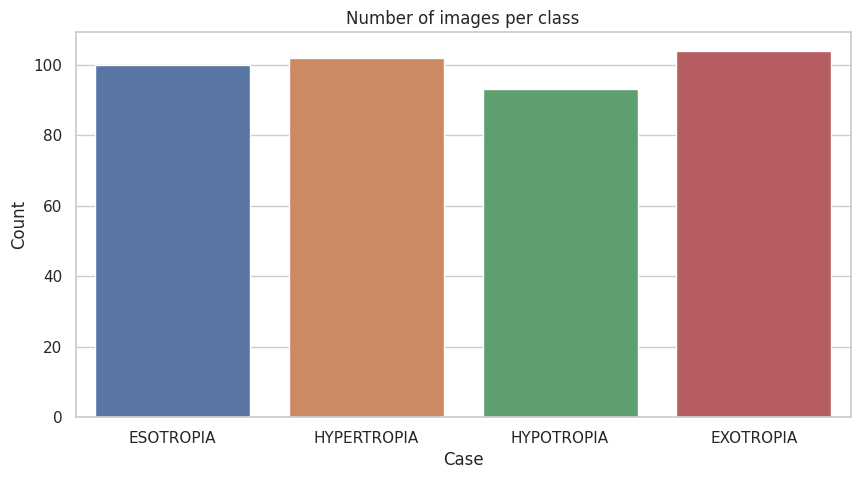

In [22]:
# Print the number of images per class
import seaborn as sns
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))
sns.barplot(x='Case', y='Count', data=treated_data)
plt.title('Number of images per class')
plt.show()

In [23]:
# Convertendo as listas para numpy
images = np.array(images)
labels = np.array(labels)

In [24]:
print(images.shape)
print(labels.shape)

(399, 96, 224, 3)
(399,)


In [25]:
# Realizando o one hot encoding
num_of_classes = len(classes)
labels = tf.keras.utils.to_categorical(labels, num_of_classes)

In [26]:
# Shuffle dataset
indices = np.arange(len(images))
np.random.shuffle(indices)


In [27]:
images = images[indices]
labels = labels[indices]

In [28]:
# Separando as imagens
train_images = images[:int(0.68*len(images))]
train_labels = labels[:int(0.68*len(labels))]
val_images = images[int(0.68*len(images)):int(0.7*len(images))]
val_labels = labels[int(0.68*len(images)):int(0.7*len(images))]
test_images = images[int(0.7*len(images)):]
test_labels = labels[int(0.7*len(labels)):]

In [29]:
print(train_images.shape)
print(train_labels.shape)
print(test_images.shape)
print(test_labels.shape)
print(val_images.shape)
print(val_labels.shape)

(271, 96, 224, 3)
(271, 4)
(120, 96, 224, 3)
(120, 4)
(8, 96, 224, 3)
(8, 4)


In [30]:
set_of_labels = np.argmax(test_labels, axis=1)
set_of_labels.shape

(120,)

In [31]:
test_labels_list = [classes[x] for x in set_of_labels]

In [32]:
pd.Series(test_labels_list).value_counts()

EXOTROPIA      33
ESOTROPIA      30
HYPOTROPIA     30
HYPERTROPIA    27
dtype: int64

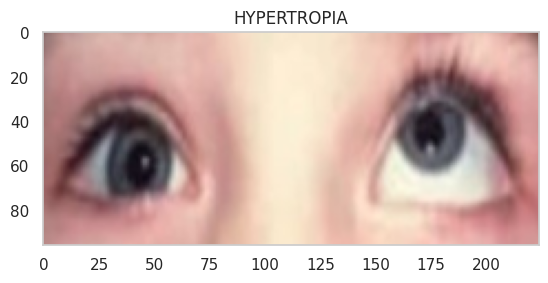

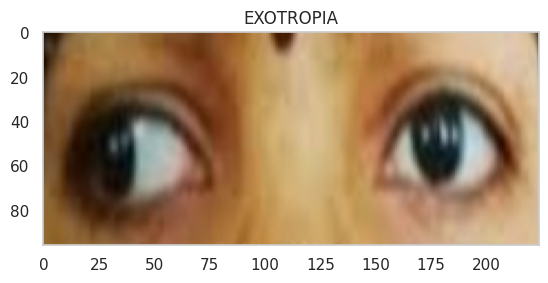

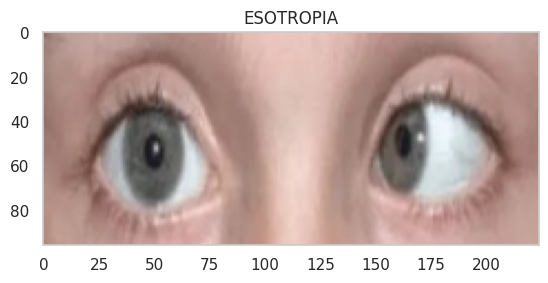

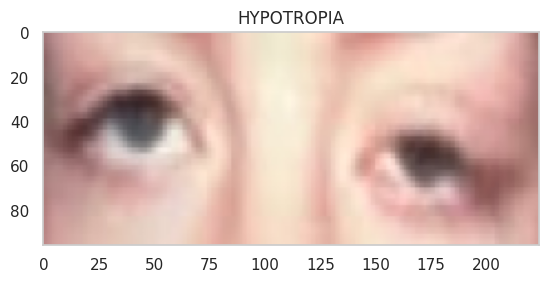

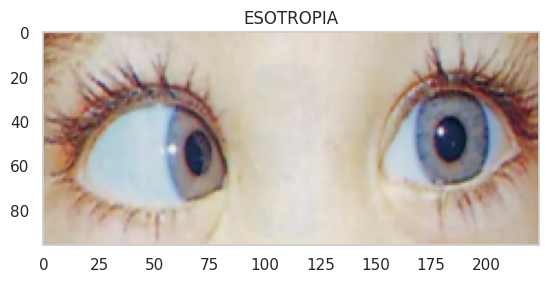

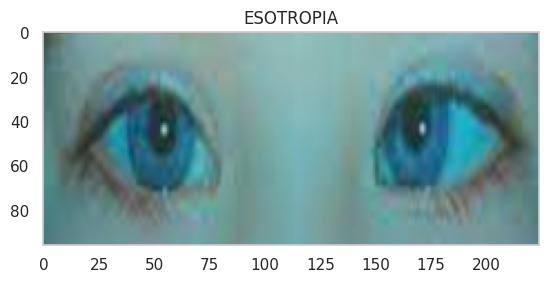

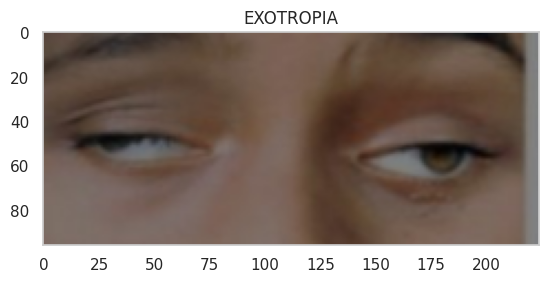

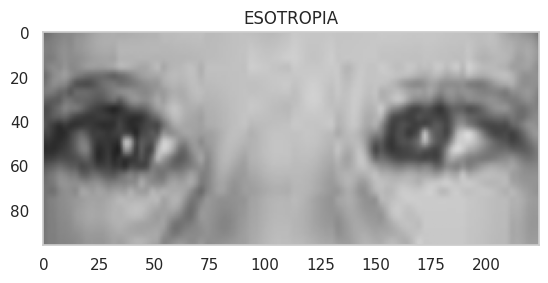

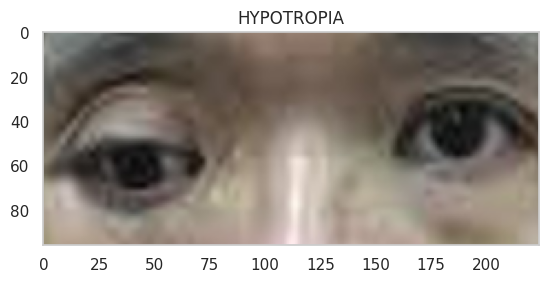

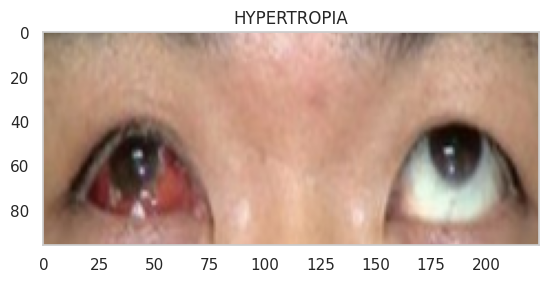

In [33]:
# print some images
for i in range(10):
    plt.imshow(train_images[i])
    plt.title(classes[np.argmax(train_labels[i])])
    plt.grid(False)
    plt.show()

In [34]:
input_shape = train_images.shape[1:]
print(input_shape)

(96, 224, 3)


In [35]:
# Carregando o Modelo baseado na Resnet50
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)
base_model.trainable = False

2025-03-07 12:54:36.708484: I tensorflow/core/platform/cpu_feature_guard.cc:142] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-03-07 12:54:36.708946: I tensorflow/compiler/jit/xla_gpu_device.cc:99] Not creating XLA devices, tf_xla_enable_xla_devices not set


In [36]:
# Customizando o modelo
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(512, activation='relu')(x)

predictions = Dense(num_of_classes, activation='softmax')(x)

In [37]:
# Juntando o modelo completo
model = Model(inputs=base_model.input, outputs=predictions)

In [38]:
model.compile(optimizer=optimizers.Adam(learning_rate = 0.0001), loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "model"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_1 (InputLayer)            [(None, 96, 224, 3)] 0                                            
__________________________________________________________________________________________________
conv1_pad (ZeroPadding2D)       (None, 102, 230, 3)  0           input_1[0][0]                    
__________________________________________________________________________________________________
conv1_conv (Conv2D)             (None, 48, 112, 64)  9472        conv1_pad[0][0]                  
__________________________________________________________________________________________________
conv1_bn (BatchNormalization)   (None, 48, 112, 64)  256         conv1_conv[0][0]                 
______________________________________________________________________________________________

In [39]:
tensorboard_callback = callbacks.TensorBoard(log_dir='../logs')

2025-03-07 12:54:48.534022: I tensorflow/core/profiler/lib/profiler_session.cc:136] Profiler session initializing.
2025-03-07 12:54:48.534041: I tensorflow/core/profiler/lib/profiler_session.cc:155] Profiler session started.
2025-03-07 12:54:48.537810: I tensorflow/core/profiler/lib/profiler_session.cc:172] Profiler session tear down.


In [40]:
class TestEvaluationCallback(callbacks.Callback):
    def __init__(self, test_data, filepath):
        super(TestEvaluationCallback, self).__init__()
        self.test_data = test_data
        self.test_losses = []
        self.test_accuracies = []
        self.best_accuracy  = 0.5
        self.filepath = filepath
        self.current_time = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

    def on_epoch_end(self, epoch, logs=None):
        x, y = self.test_data
        loss, accuracy = self.model.evaluate(x, y, verbose=0)
        self.test_losses.append(loss)
        self.test_accuracies.append(accuracy)
        print(f"\nEpoch: {epoch + 1} Test Loss: {loss:.4f}, Test Accuracy: {accuracy:.4f}")

        if accuracy > self.best_accuracy:
            x, y = self.test_data
            loss, accuracy = self.model.evaluate(x, y, verbose=0)
            self.test_losses.append(loss)
            self.test_accuracies.append(accuracy)
            print(f"\nEpoch: {epoch + 1} Test Loss: {loss:.4f}, Test Accuracy: {accuracy:.4f}")

            self.best_accuracy = accuracy
            date = self.current_time[:self.current_time.index("-")]
            fileName = os.path.join(self.filepath, f"best_model_{date}.h5")
            self.model.save(fileName)
            print(f"Saved best model with accuracy: {accuracy:.4f}")
    
    def on_train_end(self, logs=None):
        fig, ax = plt.subplots(1, 2, figsize=(10, 5))
        ax[0].plot(self.test_accuracies, label='Accuracy')
        ax[0].set_title('Model Test Accuracy')
        ax[0].set_ylabel('Accuracy')
        ax[0].set_xlabel('Epoch')
        ax[0].grid(True)

        ax[1].plot(self.test_losses, label='Loss')
        ax[1].set_title('Model Test Loss')
        ax[1].set_ylabel('Loss')
        ax[1].set_xlabel('Epoch')
        ax[1].grid(True)
        plt.title('Model Test Loss and Accuracy')
        plt.show()
                

In [43]:
if not os.path.exists(model_path):
    os.makedirs(model_path)
test_eval_callback = TestEvaluationCallback((test_images, test_labels), model_path)

Epoch 1/2000
 2/68 [..............................] - ETA: 7s - loss: 1.1373 - accuracy: 0.6875  

2025-03-07 07:52:47.679394: I tensorflow/core/profiler/lib/profiler_session.cc:136] Profiler session initializing.
2025-03-07 07:52:47.679422: I tensorflow/core/profiler/lib/profiler_session.cc:155] Profiler session started.


 5/68 [=>............................] - ETA: 7s - loss: 0.9879 - accuracy: 0.6533

2025-03-07 07:52:47.933788: I tensorflow/core/profiler/lib/profiler_session.cc:71] Profiler session collecting data.
2025-03-07 07:52:47.938162: I tensorflow/core/profiler/lib/profiler_session.cc:172] Profiler session tear down.
2025-03-07 07:52:47.941803: I tensorflow/core/profiler/rpc/client/save_profile.cc:137] Creating directory: ../logs/train/plugins/profile/2025_03_07_07_52_47
2025-03-07 07:52:47.944650: I tensorflow/core/profiler/rpc/client/save_profile.cc:143] Dumped gzipped tool data for trace.json.gz to ../logs/train/plugins/profile/2025_03_07_07_52_47/pedro-Z590-AORUS-ELITE.trace.json.gz
2025-03-07 07:52:47.948808: I tensorflow/core/profiler/rpc/client/save_profile.cc:137] Creating directory: ../logs/train/plugins/profile/2025_03_07_07_52_47
2025-03-07 07:52:47.948883: I tensorflow/core/profiler/rpc/client/save_profile.cc:143] Dumped gzipped tool data for memory_profile.json.gz to ../logs/train/plugins/profile/2025_03_07_07_52_47/pedro-Z590-AORUS-ELITE.memory_profile.json.gz

68/68 [==============================] - 7s 69ms/step - loss: 1.2130 - accuracy: 0.6658 - val_loss: 0.9633 - val_accuracy: 0.5000

Epoch: 1 Test Loss: 0.9077, Test Accuracy: 0.6583

Epoch: 1 Test Loss: 0.9077, Test Accuracy: 0.6583
Saved best model with accuracy: 0.6583
Epoch 2/2000
68/68 [==============================] - 4s 57ms/step - loss: 1.1356 - accuracy: 0.6843 - val_loss: 0.5282 - val_accuracy: 0.8750

Epoch: 2 Test Loss: 0.7517, Test Accuracy: 0.7667

Epoch: 2 Test Loss: 0.7517, Test Accuracy: 0.7667
Saved best model with accuracy: 0.7667
Epoch 3/2000
68/68 [==============================] - 4s 57ms/step - loss: 1.0092 - accuracy: 0.6556 - val_loss: 0.8628 - val_accuracy: 0.5000

Epoch: 3 Test Loss: 0.8224, Test Accuracy: 0.7500
Epoch 4/2000
68/68 [==============================] - 4s 57ms/step - loss: 0.8435 - accuracy: 0.7067 - val_loss: 0.5364 - val_accuracy: 0.8750

Epoch: 4 Test Loss: 0.7947, Test Accuracy: 0.8250

Epoch: 4 Test Loss: 0.7947, Test Accuracy: 0.8250
Saved 

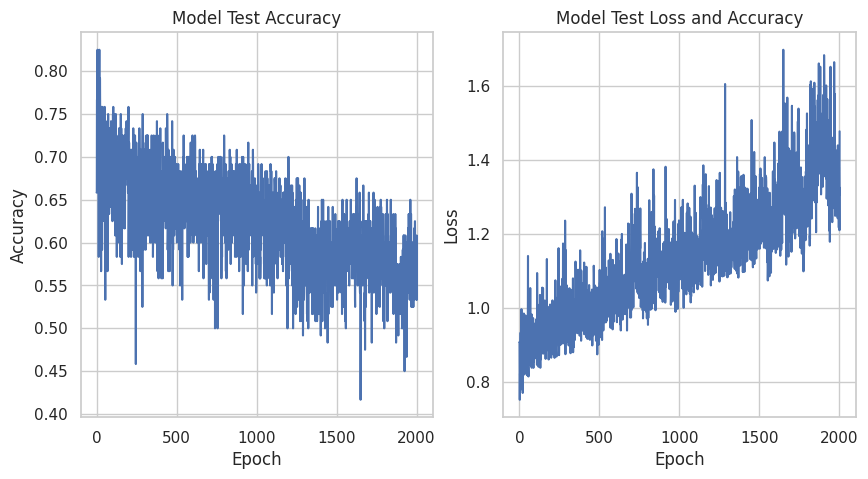

In [256]:
# Train the Model
epochs = 2000
history = model.fit(train_images, train_labels, epochs=epochs, batch_size=4, validation_data=(val_images, val_labels), callbacks=[tensorboard_callback, test_eval_callback])

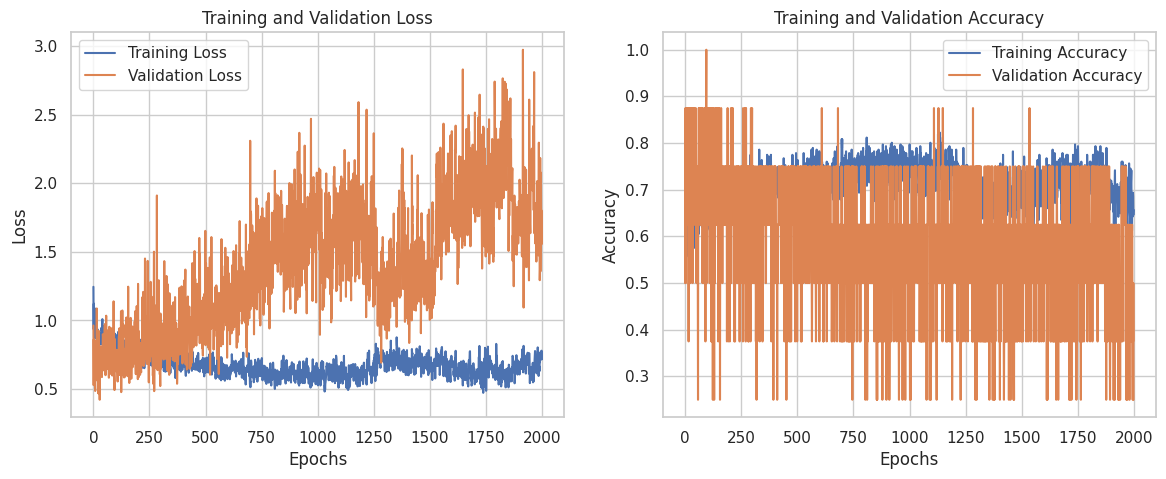

In [257]:
# Imprimindo o histórico de treinamento
# Loss
plt.figure(figsize = (14,5))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label = 'Training Loss')
plt.plot(history.history['val_loss'], label = 'Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label = 'Training Accuracy')
plt.plot(history.history['val_accuracy'], label = 'Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

In [53]:
# Model Evaluator
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, roc_curve, auc

class model_evaluator():
    def __init__(self, model_path, results_path, test_images, test_labels, classes):
        self.model_path = model_path
        self.test_images = test_images
        self.test_labels = test_labels
        self.model = tf.keras.models.load_model(self.model_path)
        self.class_names = classes
        self.results_path = results_path

    def evaluate_model(self):
        predictions = self.model.predict(self.test_images)
        y_pred = np.argmax(predictions, axis=1)
        y_true = np.argmax(self.test_labels, axis=1)

        # Confusion Matrix
        cm = confusion_matrix(y_true, y_pred)
        print(cm)

        # Classification Report
        cr = classification_report(y_true, y_pred, target_names=self.class_names)
        print(cr)

        # Calculate Specificity and Sensitivity
        sensitivity = {}
        specificity = {}
        accuracy = {}
        precision = {}
        f1_score = {}

        for i in range(len(self.class_names)):
            TP = cm[i, i]
            FN = np.sum(cm[i, :]) - TP
            FP = np.sum(cm[:, i]) - TP
            TN = np.sum(cm) - TP - FN - FP

            sensitivity[self.class_names[i]] = round(TP / (TP + FN), 2)
            specificity[self.class_names[i]] = round(TN / (TN + FP), 2)
            accuracy[self.class_names[i]] = round((TP + TN) / (TP + TN + FP + FN), 2)
            precision[self.class_names[i]] = round(TP / (TP + FP))
            f1_score[self.class_names[i]] = round(2 * TP / (2 * TP + FP + FN), 2)

        # Print Sensitivity and Specificity for every class
        for key, value in sensitivity.items():
            print(f'{key} Sensitivity: {value}')
            print(f'{key} Specificity: {specificity[key]}')

        self.save_results(sensitivity, specificity,f1_score, accuracy, precision)

    # Plotting the ROC Curve
    def plot_roc_curve(self):
        plt.figure(figsize=(10, 10))
        for i in range(len(self.class_names)):
            fpr, tpr, _ = roc_curve(self.test_labels[:, i], self.model.predict(self.test_images)[:, i])
            roc_auc = auc(fpr, tpr)
            plt.plot(fpr, tpr, label=f'{self.class_names[i]} (AUC = {roc_auc:.2f})')
        
        plt.plot([0, 1], [0, 1], 'k--', lw=2)  # Diagonal line for random classifier
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('Receiver Operating Characteristic (ROC) Curves')
        plt.legend(loc="lower right")
        plt.show()

    # Save results to a file
    def save_results(self, sensitivity, specificity,f1_score, accuracy, precision):
        df_result = pd.DataFrame([sensitivity, specificity, f1_score, accuracy, precision])
        df_result.index = ['Sensitivity', 'Specificity', 'F1 Score', 'Accuracy', 'Precision']
        df_result.to_csv(self.results_path + ".csv")
        
        



    
    

In [54]:
evaluator = model_evaluator(model_path + '/best_model_20250307.h5', results_dir, test_images, test_labels, classes)
evaluator.evaluate_model()


[[29  1  0  0]
 [ 1 29  1  2]
 [ 2  4 20  1]
 [ 2  4  3 21]]
              precision    recall  f1-score   support

   ESOTROPIA       0.85      0.97      0.91        30
   EXOTROPIA       0.76      0.88      0.82        33
 HYPERTROPIA       0.83      0.74      0.78        27
  HYPOTROPIA       0.88      0.70      0.78        30

    accuracy                           0.82       120
   macro avg       0.83      0.82      0.82       120
weighted avg       0.83      0.82      0.82       120

ESOTROPIA Sensitivity: 0.97
ESOTROPIA Specificity: 0.94
EXOTROPIA Sensitivity: 0.88
EXOTROPIA Specificity: 0.9
HYPERTROPIA Sensitivity: 0.74
HYPERTROPIA Specificity: 0.96
HYPOTROPIA Sensitivity: 0.7
HYPOTROPIA Specificity: 0.97


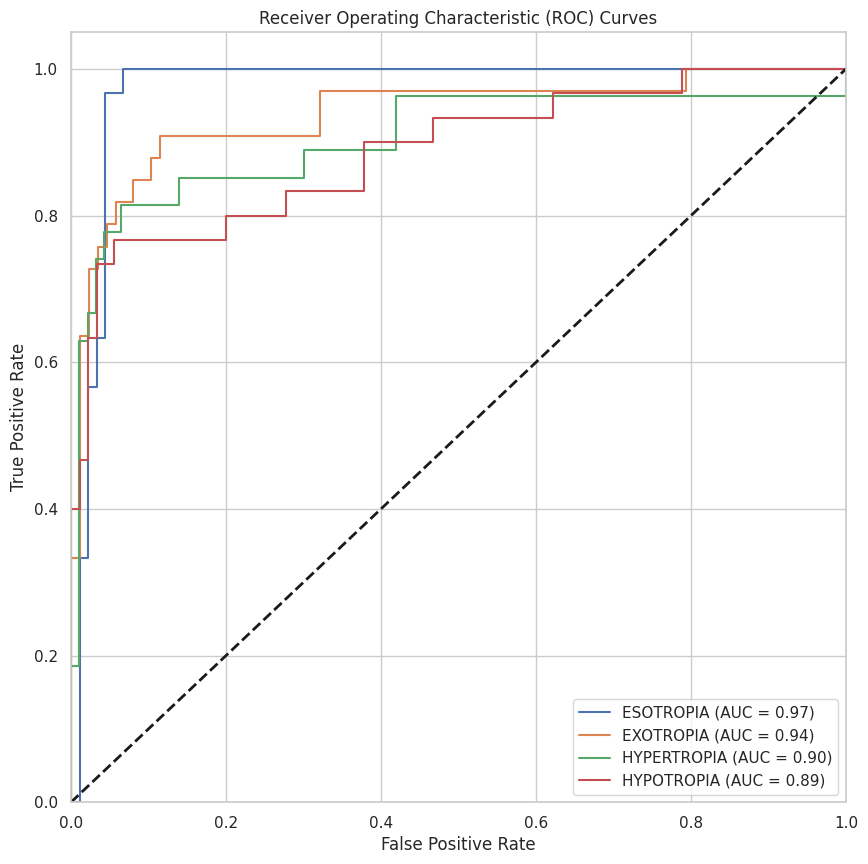

In [260]:
evaluator.plot_roc_curve()

In [ ]:
results_df = pd.read_csv(results_dir + ".csv")

AttributeError: 'str' object has no attribute 'head'